In [1]:
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import collections
import glob
import ast
import csv
import ast
import json
import requests
import random
import networkx as nx
import itertools

In [72]:
def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

In [73]:
rn2cpds_SI = csv2dict('../data/assets/rn2cpds_SI.csv')

In [3]:
# fastest run
result = pd.read_pickle(f'../runs/2024-06-17_19-39-53_check_pull-request.pkl.gz')

In [19]:
folditer2folds = {}
for k,v in result.folds_folditer.items():
    if v not in folditer2folds:
        folditer2folds[v] = [k]
    else:
        folditer2folds[v].append(k)
        
folditer2folds

{0: ['fold_independent'],
 1: ['spontaneous'],
 2: ['2002'],
 3: ['1'],
 4: ['2487'],
 5: ['2006'],
 6: ['2003'],
 7: ['246'],
 8: ['7542'],
 9: ['210'],
 10: ['7525'],
 11: ['304'],
 12: ['7518'],
 13: ['4126'],
 14: ['218'],
 15: ['2007'],
 16: ['12'],
 17: ['11'],
 18: ['109'],
 19: ['10'],
 20: ['7515'],
 21: ['279'],
 22: ['7577'],
 23: ['3016'],
 24: ['281'],
 25: ['7528'],
 26: ['331'],
 27: ['301'],
 28: ['2011'],
 29: ['7572'],
 30: ['325'],
 31: ['206'],
 32: ['282'],
 33: ['7527'],
 34: ['805'],
 35: ['3691'],
 36: ['62'],
 37: ['7560'],
 38: ['7579'],
 39: ['7512'],
 40: ['7529'],
 41: ['180'],
 42: ['7554'],
 43: ['297'],
 44: ['286'],
 45: ['4002'],
 46: ['315'],
 47: ['2004'],
 48: ['205'],
 49: ['7580'],
 50: ['70'],
 51: ['7571'],
 52: ['387'],
 53: ['7561'],
 54: ['2'],
 55: ['5104'],
 56: ['7574'],
 57: ['307'],
 58: ['7567'],
 59: ['5'],
 60: ['208'],
 61: ['7516'],
 62: ['7510'],
 63: ['7517'],
 64: ['247'],
 65: ['212'],
 66: ['2484'],
 67: ['64'],
 68: ['810'],
 

In [57]:
folditer2rns = {}
for k,v in result.rns_folditer.items():
    if v not in folditer2rns:
        folditer2rns[v] = [k]
    else:
        folditer2rns[v].append(k)
        
len(folditer2rns[1]), len(folditer2rns[2]), len(folditer2rns[3])

(54, 17, 20)

In [122]:
folditer2cpds = {}
for k,v in result.cpds_folditer.items():
    if v not in folditer2cpds:
        folditer2cpds[v] = [k]
    else:
        folditer2cpds[v].append(k)
        
len(folditer2cpds[0]), len(folditer2cpds[1]), len(folditer2cpds[2]), len(folditer2cpds[3])

(80, 20, 6, 8)

In [124]:
for k,v in folditer2cpds.items():
    print(k, len(v))

0 80
1 20
2 6
3 8
4 9
6 5
7 3
8 4
9 4
13 1
14 126
15 13
16 4
17 8
18 10
19 3
20 4
22 15
23 33
24 8
25 1
26 1
28 6
30 5
31 3
32 6
37 12
38 3
43 1
44 2
45 2
46 1
48 10
53 6
57 1
58 1
59 1
64 2
68 2
75 2
76 1
79 5
81 8
82 1
84 2
86 2
87 1
88 2
92 1
96 2
100 1
102 1
107 552
108 97
109 13
110 6
111 12
112 4
113 1
114 2
115 1
116 10
117 166
118 1
119 7
121 7
122 2
123 1
124 25
125 2
127 5
128 12
129 2
131 2
132 3
133 189
134 6
135 82
136 255
137 9
139 3
140 64
143 1
144 8
145 1
146 1
147 1
148 1
149 4
151 5
154 7
160 1
161 1
162 3
163 353
164 12
165 6
168 1
171 8
172 51
173 3
174 60
178 1
184 2
190 2
191 3
192 18
194 17
195 2
197 5
198 3
200 1
202 3
206 3
208 8
212 1
215 1
218 1
222 3
225 1
226 30
230 204
232 12
234 10
236 2
238 2
239 5
240 45
242 2
243 2
249 3
250 1
252 1
260 7
261 1
271 1
272 1
273 7
275 71
278 1
279 266
280 3
282 4
283 2
294 4
295 3
299 1
301 845
302 17
304 5
306 14
307 13
311 20
313 10
314 16
315 7
316 5
317 27
318 1
319 2
321 1
322 1
323 1
326 1
329 1
341 1
352 8
353 2


# draw

In [237]:
seed = {}
for combo in itertools.combinations(connected_seed, 2):
    seed[combo] = 100

In [238]:
expansion = {}
for rn in folditer2rns[1]:
    for c in rn2cpds_SI[rn]:
        if c[-6:] not in folditer2cpds[0]:  # new cpd
            expansion[c] = rn2cpds_SI[rn]
            
combo = {}
for key, values in expansion.items():
    combinations = [(key, value) for value in values]
    for tup in combinations:
        if not (tup[0] in folditer2cpds[0] and tup(2) in folditer2cpds[0]):  # remove intra-seed edges
            combo[tup] = 1

In [239]:
seed.update(combo)

In [241]:
# Define a function to determine the color of an edge based on its weight
def get_edge_color(weight):
    if weight == 100:
        return 'gray'
    elif weight == 1:
        return 'cyan'
    else:
        return 'magenta'

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_5119/1551129258.py:23: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, edge_color=edge_colors, alpha=0.7)


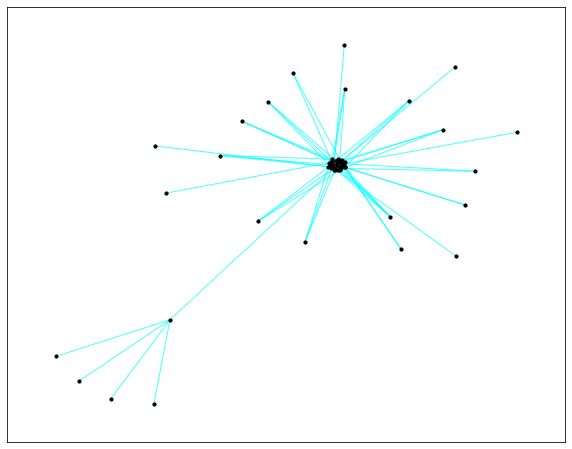

In [242]:
data = seed

# Create a graph
G = nx.Graph()

# Add edges with weights, avoiding self-referential edges
for (source, target), weight in data.items():
    if source != target and weight != 0:
        G.add_edge(source, target, weight=weight)
    elif source == target:
        G.add_node(source)  # Ensure self-referential nodes are still added

# Get edge colors based on weights
edge_colors = [get_edge_color(G[u][v]['weight']) for u, v in G.edges()]

# Draw the graph
fig, ax = plt.subplots(figsize=(10, 8))  # Adjust the figure size
pos = nx.spring_layout(G, scale=10, k=0.2)  # You can use other layouts as well
labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_nodes(G, pos, node_size=10, node_color="black", ax=ax)
# Draw edges with specific colors
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, alpha=0.7)

# plt.savefig('codep_network.png')
plt.show()

In [230]:
connected_seed = set()
for c, values in expansion.items():
    for cpd in values:
        if cpd in folditer2cpds[0]:
            connected_seed.add(cpd)

for c, values in expansion2.items():
    for cpd in values:
        if cpd in folditer2cpds[0]:
            connected_seed.add(cpd)
connected_seed

{'C00001',
 'C00009',
 'C00011',
 'C00014',
 'C00022',
 'C00025',
 'C00026',
 'C00028',
 'C00030',
 'C00033',
 'C00036',
 'C00037',
 'C00048',
 'C00065',
 'C00069',
 'C00071',
 'C00122',
 'C00160',
 'C00161',
 'C00188',
 'C00238',
 'C00288',
 'C01127',
 'C01528',
 'C01732',
 'Z00006',
 'Z00015',
 'Z00029',
 'Z00054',
 'Z00055',
 'Z00063'}

In [243]:
expansion2 = {}
for i in range(2, 7):
    if i in folditer2rns:
        for rn in folditer2rns[i]:
            for c in rn2cpds_SI[rn]:
                if c[-6:] not in (set(folditer2cpds[0]) | set(folditer2cpds[1])):  # new cpd
                    expansion2[c] = rn2cpds_SI[rn]
            
combo2 = {}
for key, values in expansion2.items():
    combinations = [(key, value) for value in values]
    for tup in combinations:
        if not (tup[0] in folditer2cpds[0] and tup(2) in folditer2cpds[0]):  # remove intra-seed edges
            combo2[tup] = 2

In [244]:
seed.update(combo2)

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_5119/3122746614.py:24: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, edge_color=edge_colors, alpha=0.7)


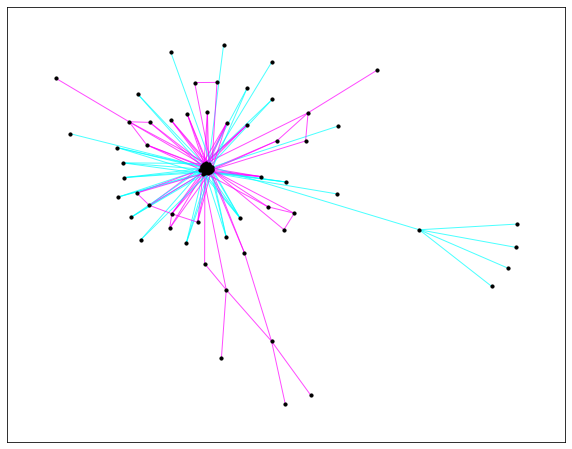

In [245]:
data = seed

# Create a graph
G = nx.Graph()

# Add edges with weights, avoiding self-referential edges
for (source, target), weight in data.items():
    if source != target and weight != 0:
        G.add_edge(source, target, weight=weight)
    elif source == target:
        G.add_node(source)  # Ensure self-referential nodes are still added

# Get edge colors based on weights
edge_colors = [get_edge_color(G[u][v]['weight']) for u, v in G.edges()]

# Draw the graph
fig, ax = plt.subplots(figsize=(10, 8))  # Adjust the figure size
pos = nx.spring_layout(G, scale=10, k=0.2)  # You can use other layouts as well
labels = nx.get_edge_attributes(G, 'weight')

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=10, node_color="black", ax=ax)
# Draw edges with specific colors
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, alpha=0.7)


plt.savefig('network_animation.svg', dpi=300, bbox_inches='tight')
plt.show()